# Ensemble Learning: Random Forest vs. XGBoost

**Goal:** Single models have limits. This notebook trains a Random Forest
and an XGBoost classifier on the Titanic dataset, compares them against the
earlier single Logistic Regression model (Task 3 / Task 5), and compares
which features each ensemble considers most important.

**Dataset:** Titanic (same dataset used in Tasks 1-3, 5, 7).


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("titanic.csv")
df.shape


(891, 12)

## 2. Clean and prepare the data (same approach as earlier tasks)

In [2]:
df_clean = df.copy()
df_clean["Age"] = df_clean.groupby(["Pclass", "Sex"])["Age"].transform(lambda x: x.fillna(x.median()))
df_clean["HasCabin"] = df_clean["Cabin"].notnull().astype(int)
df_clean = df_clean.drop(columns=["Cabin"])
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])
df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1

features = df_clean.drop(columns=["PassengerId", "Name", "Ticket", "Survived"])
target = df_clean["Survived"]
features_encoded = pd.get_dummies(features, columns=["Sex", "Embarked"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, target, test_size=0.2, random_state=42, stratify=target
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (712, 10)  Test: (179, 10)


## 3. Baseline — Logistic Regression (from Task 3 / Task 5)

In [3]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)


## 4. Train a Random Forest

In [4]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


## 5. Train an XGBoost classifier

In [5]:
xgb = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    random_state=42, eval_metric="logloss"
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)


## 6. Compare all three models

In [6]:
def eval_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
    }

comparison = pd.DataFrame([
    eval_model("Logistic Regression (baseline)", y_test, y_pred_lr),
    eval_model("Random Forest", y_test, y_pred_rf),
    eval_model("XGBoost", y_test, y_pred_xgb),
]).round(4)
comparison


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression (baseline),0.8101,0.7778,0.7101,0.7424
1,Random Forest,0.7933,0.7667,0.6667,0.7132
2,XGBoost,0.7821,0.7419,0.6667,0.7023


In [7]:
for name, y_pred in [("Logistic Regression", y_pred_lr), ("Random Forest", y_pred_rf), ("XGBoost", y_pred_xgb)]:
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["Did not survive", "Survived"]))


--- Logistic Regression ---
                 precision    recall  f1-score   support

Did not survive       0.83      0.87      0.85       110
       Survived       0.78      0.71      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.80       179
   weighted avg       0.81      0.81      0.81       179

--- Random Forest ---
                 precision    recall  f1-score   support

Did not survive       0.81      0.87      0.84       110
       Survived       0.77      0.67      0.71        69

       accuracy                           0.79       179
      macro avg       0.79      0.77      0.78       179
   weighted avg       0.79      0.79      0.79       179

--- XGBoost ---
                 precision    recall  f1-score   support

Did not survive       0.80      0.85      0.83       110
       Survived       0.74      0.67      0.70        69

       accuracy                           0.78       179
      macro av

## 7. Feature importances — Random Forest vs. XGBoost

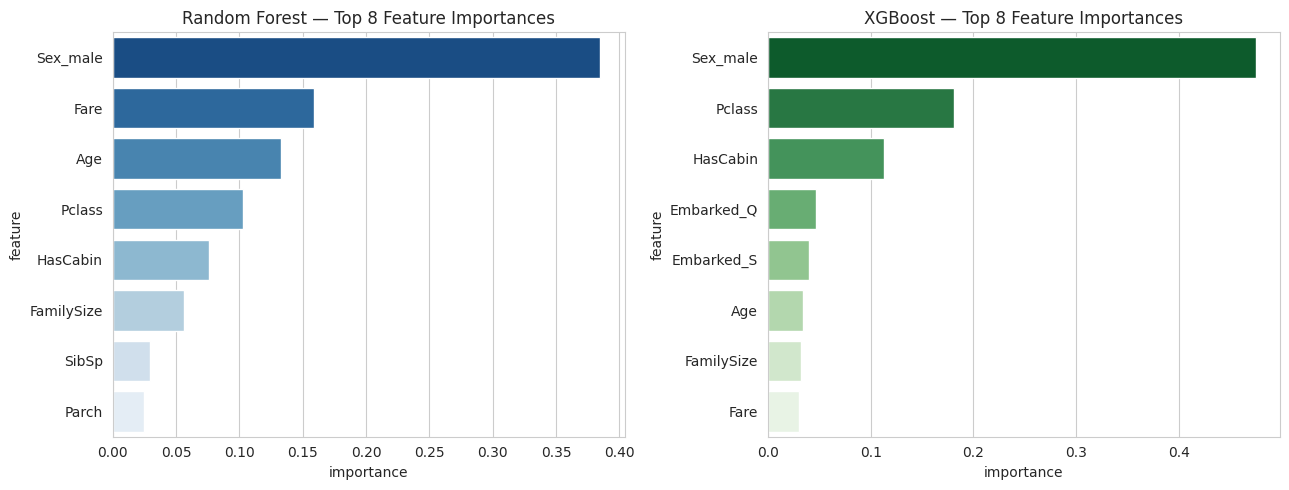

Random Forest top 5:
    feature  importance
7  Sex_male    0.385023
4      Fare    0.159233
1       Age    0.132874
0    Pclass    0.102947
5  HasCabin    0.076003

XGBoost top 5:
      feature  importance
7    Sex_male    0.474543
0      Pclass    0.180831
5    HasCabin    0.113261
8  Embarked_Q    0.047156
9  Embarked_S    0.039886


In [8]:
rf_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

xgb_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x="importance", y="feature", data=rf_importances.head(8), hue="feature", palette="Blues_r", legend=False, ax=axes[0])
axes[0].set_title("Random Forest — Top 8 Feature Importances")
sns.barplot(x="importance", y="feature", data=xgb_importances.head(8), hue="feature", palette="Greens_r", legend=False, ax=axes[1])
axes[1].set_title("XGBoost — Top 8 Feature Importances")
plt.tight_layout()
plt.show()

print("Random Forest top 5:")
print(rf_importances.head(5))
print()
print("XGBoost top 5:")
print(xgb_importances.head(5))


Both models agree that **`Sex_male`** and **`Fare`**/**`Pclass`** are among
the most important predictors, consistent with everything we've seen since
the Task 2 EDA. Where they tend to differ: Random Forest's importances are
usually spread a bit more evenly across several features (it averages over
many decorrelated trees), while XGBoost's importances are often more
concentrated on fewer top features, since each new tree specifically targets
the errors of the previous ones and tends to keep leaning on whichever
features most reduce that remaining error.


## 8. How do Random Forest and XGBoost differ in how they combine models?

Both are ensembles of decision trees, but they combine them differently.
**Random Forest** builds many trees independently and in parallel, each on a
random subset of the data and features (bagging), then averages/votes their
predictions together — the randomness and independence between trees is
what reduces overfitting. **XGBoost** builds trees sequentially (boosting):
each new tree is trained specifically to correct the errors made by the
trees built before it, with the model improving step by step rather than
all at once. This makes XGBoost typically more accurate when tuned well,
but also more prone to overfitting if not carefully regularized, whereas
Random Forest is generally more robust "out of the box" with less tuning.
